/var/folders/vc/zqm44p0x6dx4m48jclbr5q280000gn/T/ipykernel_10149/1099609908.py:81: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Year', y='Difference', hue='Sector', data=melted_data, ci=None)


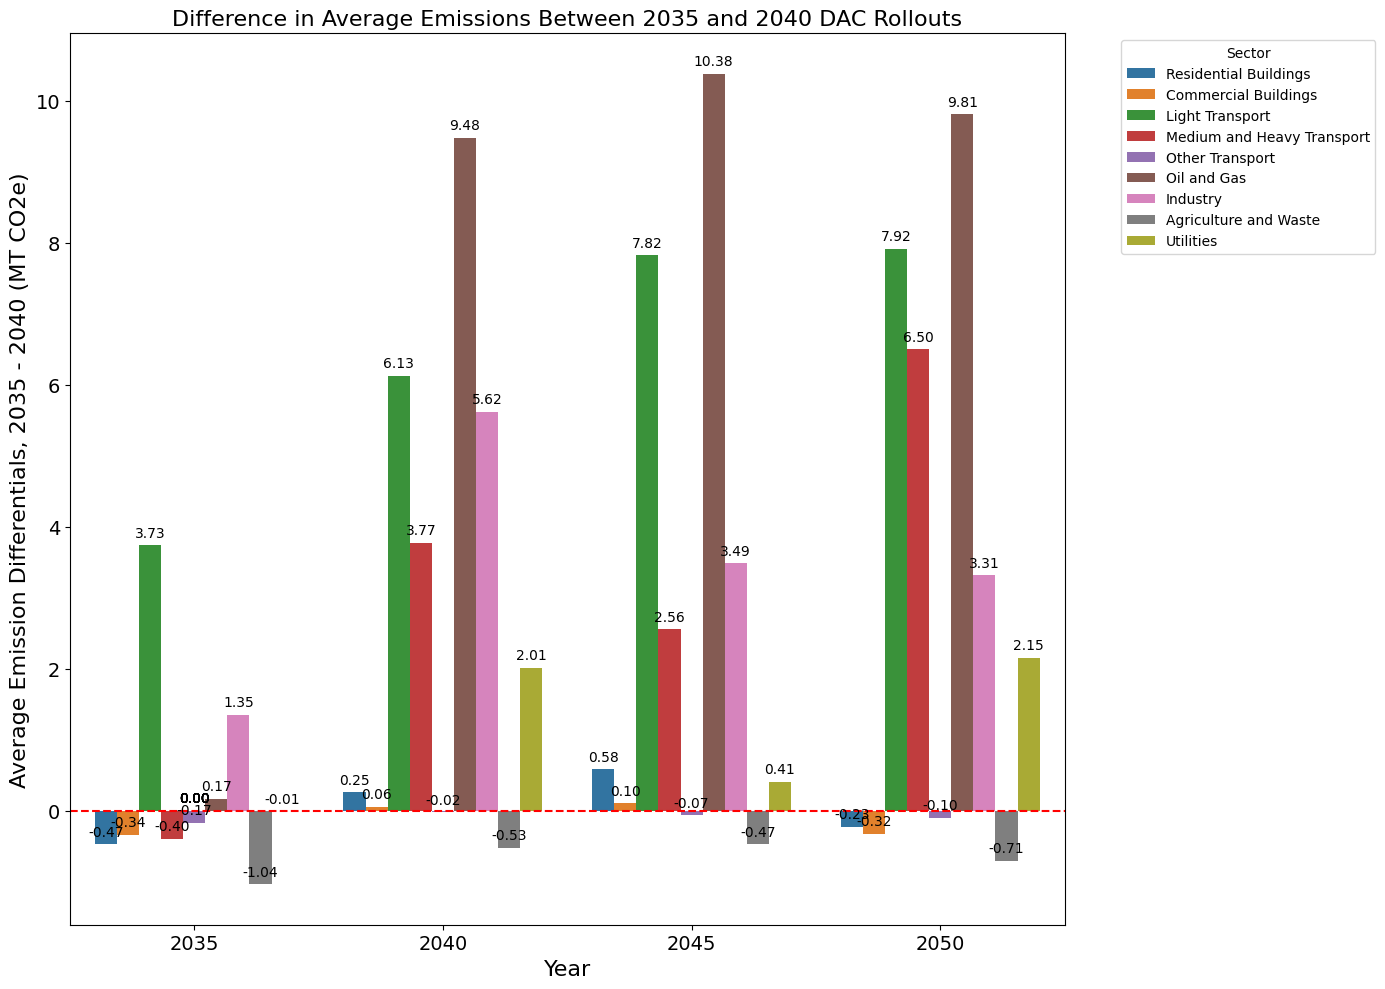

'\nimport numpy as np\nimport scipy.stats as stats\n\n# Assuming the correct DataFrame (merged_data) was created earlier\n# Make sure to list the column names correctly\n\n# Check normality for each sector using Shapiro-Wilk Test\nnormality_results = {}\nfor col in df_2035.columns[2:]:  # Iterate over the sector names (excluding \'Year\' and \'Bound\')\n    col_2035 = f\'{col}_2035\'\n    col_2040 = f\'{col}_2040\'\n    \n    # Perform Shapiro-Wilk test for the 2035 data\n    if col_2035 in merged_data.columns:\n        stat, p_value = stats.shapiro(merged_data[col_2035])\n        normality_results[col_2035] = p_value\n    \n    # Perform Shapiro-Wilk test for the 2040 data\n    if col_2040 in merged_data.columns:\n        stat, p_value = stats.shapiro(merged_data[col_2040])\n        normality_results[col_2040] = p_value\n\n# Print normality results\nprint("Shapiro-Wilk Test Results (p-value):")\nfor key, value in normality_results.items():\n    print(f"{key}: {value}")\n\n# Visual Ins

In [1]:
"""
Created on Thu Aug 29 20:13:34 2024

@author: fyabdulla
"""

import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Hard-coded data for 2035 DAC rollout
data_2035 = {
    "Year": [2035, 2035, 2035, 2040, 2040, 2040, 2045, 2045, 2045, 2050, 2050, 2050],
    "Bound": ["Min", "Max", "Avg", "Min", "Max", "Avg", "Min", "Max", "Avg", "Min", "Max", "Avg"],
    "Land Use and Forestry Sequestration (MT CO2e)": [35, 48.25, 40.45588235, 40, 66.5, 50.91176471, 45, 84.75, 61.36764706, 50, 103, 71.82352941],
    "Residential Buildings (MT CO2e)": [28.68, 31.871, 30.282, 26.338, 30.885, 28.56, 28.407, 33.089, 30.681, 30.336, 34.074, 32.105],
    "Commercial Buildings (MT CO2e)": [24.309, 26.655, 25.496, 21.558, 25.12, 23.533, 21.752, 25.265, 23.703, 21.828, 24.819, 22.766],
    "Light Transport (MT CO2e)": [47.016, 75.154, 63.406, 29.218, 67.876, 50.262, 19.103, 63.92, 42.198, 17.461, 63.672, 40.622],
    "Medium and Heavy Transport (MT CO2e)": [36.807, 71.236, 55.371, 46.534, 74.011, 63.258, 44.569, 76.977, 63.37, 44.504, 78.612, 64.264],
    "Other Transport (MT CO2e)": [14.122, 14.639, 14.41, 15.18, 15.997, 15.649, 17.085, 17.93, 17.51, 18.493, 19.349, 18.879],
    "Oil and Gas (MT CO2e)": [37.46, 109.387, 66.05, 31.108, 91.09, 54.84, 28.23, 96.156, 57.094, 26.638, 83.355, 50.87],
    "Industry (MT CO2e)": [54.51, 81.376, 68.505, 47.503, 84.015, 69.225, 59.081, 90.767, 78.322, 67.368, 88.972, 79.118],
    "Agriculture and Waste (MT CO2e)": [78.372, 84.955, 81.051, 72.404, 79.023, 75.883, 69.793, 77.026, 73.839, 68.943, 74.492, 72.184],
    "Utilities (MT CO2e)": [2.334, 5.383, 3.562, 4.265, 24.534, 6.56, 8.946, 40.072, 14.352, 10.777, 43.327, 16.727],
    "Direct Air Capture Sequestration (MT CO2e)": [0, 33.425, 13.5595908, 52.787, 148.689, 101.1538978, 162.281, 292.492, 222.412841, 262.452, 407.22, 326.8434326]
}

# Hard-coded data for 2040 DAC rollout
data_2040 = {
    "Year": [2035, 2035, 2035, 2040, 2040, 2040, 2045, 2045, 2045, 2050, 2050, 2050],
    "Bound": ["Min", "Max", "Avg", "Min", "Max", "Avg", "Min", "Max", "Avg", "Min", "Max", "Avg"],
    "Land Use and Forestry Sequestration (MT CO2e)": [35, 48.25, 45.94565217, 40, 66.5, 61.89130435, 45, 84.75, 77.83695652, 50, 103, 93.7826087],
    "Residential Buildings (MT CO2e)": [29.232, 32.395, 30.626, 26.693, 30.088, 28.24, 28.421, 31.738, 30.267, 30.275, 34.34, 32.588],
    "Commercial Buildings (MT CO2e)": [24.608, 27.08, 25.792, 21.592, 24.994, 23.456, 21.905, 24.851, 23.651, 21.875, 25.095, 23.415],
    "Light Transport (MT CO2e)": [47.34, 72.964, 54.067, 29.376, 62.926, 36.666, 17.975, 57.92, 25.855, 16.619, 57.488, 23.898],
    "Medium and Heavy Transport (MT CO2e)": [37.063, 71.798, 55.756, 46.496, 68.628, 57.357, 49.584, 70.724, 56.938, 43.951, 69.345, 54.587],
    "Other Transport (MT CO2e)": [14.272, 14.786, 14.633, 15.215, 15.929, 15.75, 17.081, 17.942, 17.7, 18.549, 19.36, 19.117],
    "Oil and Gas (MT CO2e)": [38.997, 106.088, 67.312, 31.331, 68.796, 48.473, 28.354, 75.231, 46.752, 26.97, 61.768, 42.691],
    "Industry (MT CO2e)": [55.676, 78.635, 66.025, 48.246, 74.993, 60.643, 59.924, 87.571, 70.215, 63.513, 89.229, 72.772],
    "Agriculture and Waste (MT CO2e)": [79.237, 85.834, 82.422, 72.482, 79.748, 76.662, 70.107, 77.521, 74.455, 69.683, 75.462, 72.602],
    "Utilities (MT CO2e)": [2.494, 5.444, 3.377, 4.015, 19.014, 6.285, 8.418, 40.287, 13.445, 11.738, 34.523, 18.118],
    "Direct Air Capture Sequestration (MT CO2e)": [0, 0, 0, 41.676, 70.433, 55.86615206, 143.009, 200.95, 164.0974761, 236.228, 334.087, 266.8836831]
}

# Convert to DataFrame
df_2035 = pd.DataFrame(data_2035)
df_2040 = pd.DataFrame(data_2040)

# Merge the data on the Year and Bound columns for comparison
merged_data = pd.merge(df_2035, df_2040, on=['Year', 'Bound'], suffixes=('_2035', '_2040'))

# Calculate the differences in average emissions
for col in df_2035.columns[2:]:
    merged_data[f'{col}_Difference'] = merged_data[f'{col}_2035'] - merged_data[f'{col}_2040']

# Perform Statistical Tests
# T-Test (assuming normal distribution)
ttest_results = {}
for col in df_2035.columns[2:]:
    t_stat, p_value = stats.ttest_rel(merged_data[f'{col}_2035'], merged_data[f'{col}_2040'])
    ttest_results[col] = {'t-stat': t_stat, 'p-value': p_value}

# List of sectors to exclude
exclude_sectors = ['Direct Air Capture Sequestration (MT CO2e)', 'Land Use and Forestry Sequestration (MT CO2e)']

# Filter out the excluded sectors from the merged_data DataFrame before melting
filtered_data = merged_data.drop(columns=[f'{sector}_Difference' for sector in exclude_sectors])

# Melt the filtered DataFrame to long format for easier plotting
melted_data = filtered_data.melt(id_vars=["Year"], 
                                 value_vars=[col for col in filtered_data.columns if "Difference" in col],
                                 var_name="Sector", value_name="Difference")

# Extract sector names from the variable names and remove (MT CO2e)
melted_data['Sector'] = melted_data['Sector'].str.replace('_Difference', '', regex=False)
melted_data['Sector'] = melted_data['Sector'].str.replace(' \(MT CO2e\)', '', regex=True)  # Removes "(MT CO2e)" from sector names

# Create the plot
plt.figure(figsize=(14, 10))
ax = sns.barplot(x='Year', y='Difference', hue='Sector', data=melted_data, ci=None)

# Add data labels above the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points')

plt.axhline(0, color='red', linestyle='--')
plt.title('Difference in Average Emissions Between 2035 and 2040 DAC Rollouts', fontsize=16)
plt.ylabel('Average Emission Differentials, 2035 - 2040 (MT CO2e)', fontsize=16)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Year", fontsize=16)
plt.tight_layout()
plt.show()